# Tarea 2. Gracida Salgado Angel David

Primero haremos el relleno de datos del archivo: GLT_filtrado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('GLT_filtrado.csv')


In [ ]:
#Realizmos el conteo de los datos faltantes
Faltantes=df['AverageTemperature'].isna().sum() #número de valores faltantes
print(Faltantes)

27581


In [ ]:
df.count() #contamos cuantos datos tiene el dataframe

,0
Date,219575
AverageTemperature,191994
AverageTemperatureUncertainty,191994
City,219575
Country,219575
Latitude,219575
Longitude,219575


In [ ]:
#Dado que el dataframe tiene 219575 datos, y los valores faltantes son 27581, entonces el porcentaje de estos datos respecto al conjunto total es:
print((Faltantes*100)/219575, "%")


12.561083912102927 %


In [ ]:
#Los valores faltantes representan el 12 % de los datos totales, sin embargo un menor porcentaje (menor al 10%) podría ser utilizado para eliminar dichas líneas con datos vacíos.
#No obstante, en esta ocasión conviene reemplazar los valores faltantes para no perder información.

In [ ]:
#Aplicamos el código dado en clase para rellenar valores faltantes del conjunto de datos de la temperatura promedio de la tierra

import numpy as np

def llenar_faltantes(lista): #función para rellenar valores faltantes
    # Convertir la lista a un array de NumPy, reemplazando '' con NaN
    datos = np.array([float(x) if x != '' else np.nan for x in lista])

    # Recorrer todos los elementos de la lista
    for i in range(len(datos)):
        if np.isnan(datos[i]):  # Si el valor es NaN (antes era '')
            # Buscar el valor anterior más cercano
            previo = 0
            for j in range(i-1, -1, -1):
                if not np.isnan(datos[j]):
                    previo = datos[j]
                    break

            # Buscar el valor siguiente más cercano
            siguiente = 0
            for j in range(i+1, len(datos)):
                if not np.isnan(datos[j]):
                    siguiente = datos[j]
                    break

            # Reemplazar NaN con la media de los vecinos más cercanos
            datos[i] = (previo + siguiente) / 2

    return datos.tolist()  # Convertir el array de NumPy de vuelta a lista




In [ ]:
df_copia = df.copy()

# guardar las primeras 10 filas ANTES
#antes_rellenar = df_copia[df_copia['AverageTemperature'].isna()].head(10).copy()
#print("ANTES de rellenar valores faltantes:")
#print(antes_rellenar[['City', 'AverageTemperature']])

# orden
df_copia = df_copia.sort_values(['City', 'Date'])

# aplicar la función
for ciudad in df_copia['City'].unique():
    indice_ciudad = df_copia['City'] == ciudad
    temperaturas = df_copia.loc[indice_ciudad, 'AverageTemperature'].tolist()
    Incertitem = df_copia.loc[indice_ciudad, 'AverageTemperatureUncertainty'].tolist() #rellenamos tambien los valores de la incertidumbre de la temperatura promedio
    temperaturas_rellenadas = llenar_faltantes(temperaturas)
    Incerti_rellenadas= llenar_faltantes(Incertitem)
    df_copia.loc[indice_ciudad, 'AverageTemperature'] = temperaturas_rellenadas
    df_copia.loc[indice_ciudad, 'AverageTemperatureUncertainty'] =  Incerti_rellenadas

# DESPUÉS de rellenaR
#despues_rellenar = df_copia.loc[antes_rellenar.index]
#print("\nDESPUÉS de rellenar valores faltantes:")
#print(despues_rellenar[['City', 'AverageTemperature']])


In [ ]:
df_copia.isnull().sum() #comprobamos que ya no hay valores faltantes ni en temperatura promedio ni en su incertidumbre

,0
Date,0
AverageTemperature,0
AverageTemperatureUncertainty,0
City,0
Country,0
Latitude,0
Longitude,0


Hay una anomalía en la distribución de datos. Con ayuda de Matplotlib y
el método IQR, detecta la anomalía. Para ello realiza los siguientes pasos:
1) Haz una grafica la distribución global de AverageTemperature usando
un histograma. Observas una cola anormal o valores extremadamente
grandes? 2) Calcula los límites usando el método IQR y identifica todos
los valores fuera de esos límites. Determina qué ciudad X genera la mayoría
de esos outliers.

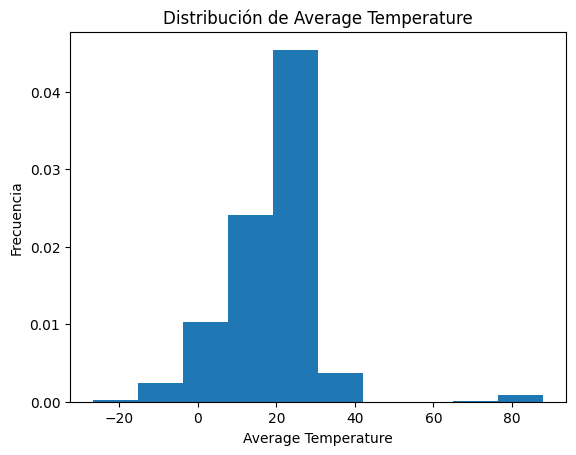

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random as rd
#Creamos el histograma de datos rellenados
plt.hist(df_copia['AverageTemperature'],alpha=1,density=True)
plt.xlabel('Average Temperature')
plt.ylabel('Frecuencia')
plt.title('Distribución de Average Temperature')
plt.show()

In [ ]:
#Aplicando el método IQR
data_no_outliers = df_copia.copy()
for col in data_no_outliers.select_dtypes(include=[np.number]).columns:
  Q1 = data_no_outliers[col].quantile(0.25) # Primer quartile (25%)
  Q3 = data_no_outliers[col].quantile(0.75) # Tercer quartile (75%)
  IQR = Q3 - Q1 # Rango interquartile
  # limites IQR
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  # contador
  outliers_count = (
  (data_no_outliers[col] < lower_bound)
  | (data_no_outliers[col] > upper_bound)
  ).sum()
  # apping
  data_no_outliers[col] = np.clip(data_no_outliers[col], lower_bound, upper_bound)
  print(f"'{col}': {outliers_count} outliers capped Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print("\nOutlier capping completed.")

'AverageTemperature': 7793 outliers capped Bounds: [-5.00, 44.75]
'AverageTemperatureUncertainty': 7686 outliers capped Bounds: [-0.99, 2.55]
'Year': 0 outliers capped Bounds: [1737.00, 2105.00]

Outlier capping completed.


In [ ]:
#Vemos que los límites con el método IQR para los valores de temperatura promedio son [-5.00,44.75], observamos datos atípicos en el extremo de 80 grados
#y en el otro extremo de -20 grados

In [ ]:
#Vamos a identificar los datos atípicos fuera de los límites IQR
H=[]
for i in df_copia['AverageTemperature']:
  if i < -5.00 or i > 44.75:
    H.append(i) #guardamos los datos en una lista H

H=pd.DataFrame(H)

In [ ]:
print(len(H)) #vemos que hay 7793 valores fuera de los límites del método IQR

7793


In [ ]:
#Vamos a ver que ciudad genera la mayoría de esos outliers

In [ ]:
P=[]#lista para guardar los datos de ciudades que cumplen con la condición de estar fuera de los límites de IQR

for i in df_copia['AverageTemperature']:
    if i < -5.00 or i > 44.75:
      indice_temp = df_copia['AverageTemperature'] ==i
      P.append(str(df_copia.loc[indice_temp,'City']).split()) #los transformamos a cadenas para quitarles el tipo series y dividimos las cadenas para extraer los datos de las ciudades posteriormente




In [ ]:
#transformamos a dataframe la lista P y eliminamos las columnas que no tengan que ver con los datos de las ciudades
DD=pd.DataFrame(P)
G=[i for i in range(2,82)] #Esta lista es para eliminar columnas del dataframe DD, puesto es que estas son numéricas, empieza desde 2 hasta la 81
DEM=DD.drop(G,axis=1)#borramos los datos que no nos interesan
#Lo que nos indica cuantos valores outliers le pertenecen, encontramos que Bangkok es la ciudad con mas de estos outliers, teniendo 2352
DEM.head() #nuevo dataframe con los nombres de las ciudades a las que pertenecen los outliers

,0,1
0,11232,Ankara
1,11472,Ankara
2,11544,Ankara
3,11736,Ankara
4,12109,Ankara


In [ ]:
DEM[1].value_counts() #contamos cuantas veces se repite cada ciudad, lo que nos indica cuantos valores outliers le pertenecen, encontramos que Bangkok es la ciudad con mas de estos outliers, teniendo 2352
#Por lo tanto X=Bangkok, es la ciudad que genera la mayoría de los outliers

,count
1,
Bangkok,2352
Harbin,859
Changchun,829
Montreal,683
Moscow,590
Shenyang,460
Saint,389
Kiev,319
Taiyuan,311


In [ ]:
#Sorprendentemente, nos damos cuenta que todos los datos de temperatura promedio de Bangkok son outliers
#Presenta temperaturas superiores a 70 grados celsius (supongo que son celsius, ya que si fuesen fahrenheit, méxico tendria temperaturas promedio de -15 grados celsius)
#Tampoco pueden ser kelvin por que todas las temperaturas serían congelantes ni ninguna otra escala.
df_copia[df_copia['City']=='Bangkok'].value_counts()

,,,,,,,,count
Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,Year,
2011-08-01,82.6826,32.7218,Bangkok,Thailand,13.66N,99.91E,2011,1
2011-07-01,82.8986,32.9288,Bangkok,Thailand,13.66N,99.91E,2011,1
2011-06-01,83.7680,32.7524,Bangkok,Thailand,13.66N,99.91E,2011,1
2011-05-01,84.6680,32.4410,Bangkok,Thailand,13.66N,99.91E,2011,1
2011-04-01,82.3046,32.4455,Bangkok,Thailand,13.66N,99.91E,2011,1
...,...,...,...,...,...,...,...,...
1817-05-01,81.2948,35.4632,Bangkok,Thailand,13.66N,99.91E,1817,1
1817-04-01,84.4268,35.2400,Bangkok,Thailand,13.66N,99.91E,1817,1
1817-03-01,82.2164,35.2796,Bangkok,Thailand,13.66N,99.91E,1817,1


Filas: 2352
Year
1817    78.614450
1818    79.718600
1819    78.604625
1820    79.174625
1821    80.256800
Name: AverageTemperature, dtype: float64


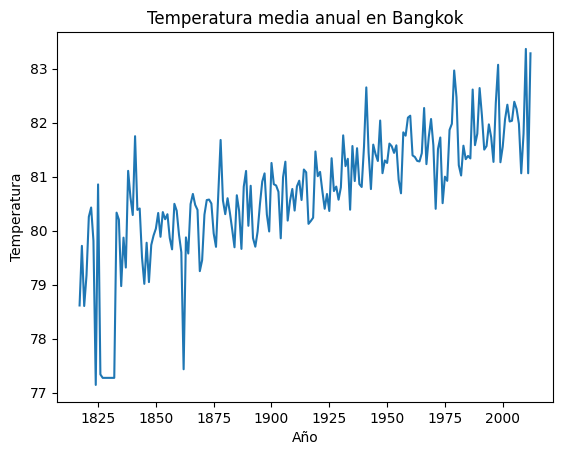

In [ ]:
#Vamos a graficar las temperaturas promedio de Bangkok en función de cada año
df_copia['Date'] = pd.to_datetime(df_copia['Date'])
df_copia['Year'] = df_copia['Date'].dt.year

ciudad = 'Bangkok'
d = df_copia[df_copia['City'] == ciudad]
print("Filas:", len(d))


media_anual = d.groupby('Year')['AverageTemperature'].mean()
print(media_anual.head())

plt.figure()
plt.plot(media_anual.index, media_anual.values)
plt.title(f'Temperatura media anual en Bangkok')
plt.xlabel('Año')
plt.ylabel('Temperatura')
plt.show()

2)Como puedes ver, la ciudad X tienen distribuciones de temperatura muy diferentes. Sin embargo, lo que resulta extrãno es la gran diferencia en la magnitud de sus temperaturas. Es posible que todos los sensores de las estaciones estuvieran defectuosos? Qué crees que pudo haber sucedido aquí? Usa tu creatividad para analizarlo y proponer una explicación.

Dado que las temperaturas promedio anuales son abismalmente diferentes al de el resto de los países (mayores a 70 grados celsius), podemos pensar en 2 posibles explicaciones que se mencionaran a acontinuación.

1) Los datos recabados fueron registrados erróneamente, es decir existieron errores sistemáticos en los medidores, o los mismos fueron alterados durante el transcurso de los años, no obstante, estamos hablando de una falla sistemática y/o alteración que viene desde 1817, lo que es muy poco probable. Por otra parte, puede haber sucediddo que el error sistemático fue cometido en un momento en el que se transcribieron los datos de base de datos en base de datos.

2) Es posible que las temperaturas registradas como "temperatura promedio anual", fueran en realidad temperaturas máximas o incluso temperaturas de sensación térmica ("realfeel" usualmente mayores a las temperaturas promedio sobre todo en ciudades con alta concentración de concreto y humedad como Bangkok) [1],[2]. La idea se basa en que las incertidumbres de la temperatura anual promedio son alrededor de 32 grados celsius, por lo que cubre valores inferiores de alrededor de 45-52 grados celsius que todavía son temperaturas alcanzadas en bangkok (pero en casos muy extremos y atípicos).


[1] AccuWeather, Inc. (2026). Tiempo diario en Bangkok, Bangkok, Tailandia. AccuWeather. Recuperado el 23 de febrero de 2026, de https://www.accuweather.com/es/th/bangkok/318849/daily-weather-forecast/318849

[2] Pakarnseree, R., Chunkao, K., & Bualert, S. (2018). Physical characteristics of Bangkok and its urban heat island phenomenon. Building and Environment, 143, 561-569. https://doi.org/10.1016/j.buildenv.2018.07.042


